In [1]:
import pandas as pd
import numpy as np
import numpy as np
import matplotlib.pyplot as plt

# Density over all kind of objects - emitters and not emitters

In [3]:
import pandas as pd
from pathlib import Path

outdir = '/mnt/hdcasa/splus_gaia/mc_catalogs/'


def concat_fields(outdir, pattern):

    pasta = Path(outdir)

    files = sorted(pasta.glob(pattern))

    full = pd.concat(
        (pd.read_csv(f) for f in files),
        ignore_index=True
    )
    return full

In [4]:
mc_fields = concat_fields(outdir, 'MC*.csv')

/tmp/ipykernel_97277/2480420889.py:13: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  full = pd.concat(


In [4]:
mc_fields.size

1210689747

In [5]:
mc_fields_clean = mc_fields[(mc_fields['err_mag_psf_j0660'] < 0.2)&
        (mc_fields['err_mag_psf_i'] < 0.2)&
        (mc_fields['err_mag_psf_r'] < 0.2)&
        (mc_fields['mag_psf_j0660']/mc_fields['err_mag_psf_j0660'] > 10)&
        (mc_fields['mag_psf_i']/mc_fields['err_mag_psf_i'] > 10)&
        (mc_fields['mag_psf_r']/mc_fields['err_mag_psf_r'] > 10)&
        mc_fields['mag_psf_r'].between(13,19.5)]

In [7]:
mc_fields_clean.columns

Index(['id', 'ra', 'dec', 'mag_psf_g', 'mag_psf_i', 'mag_psf_j0378',
       'mag_psf_j0395', 'mag_psf_j0410', 'mag_psf_j0430', 'mag_psf_j0515',
       'mag_psf_j0660', 'mag_psf_j0861', 'mag_psf_r', 'mag_psf_u', 'mag_psf_z',
       'err_mag_psf_g', 'err_mag_psf_i', 'err_mag_psf_j0378',
       'err_mag_psf_j0395', 'err_mag_psf_j0410', 'err_mag_psf_j0430',
       'err_mag_psf_j0515', 'err_mag_psf_j0660', 'err_mag_psf_j0861',
       'err_mag_psf_r', 'err_mag_psf_u', 'err_mag_psf_z'],
      dtype='object')

In [6]:
mc_emitters_all = pd.read_csv('/home/shared/splus_gaia/data/h-alpha-selection-marina/MC/halpha_emitters_mc_simbad_and_all_dist.csv')

In [7]:
mc_fields_clean["h_alpha_emitters_8sigma"] = mc_fields_clean["id"].isin(
    mc_emitters_all["splus_idr6_id"].unique()
)

/tmp/ipykernel_97277/3485438129.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mc_fields_clean["h_alpha_emitters_8sigma"] = mc_fields_clean["id"].isin(


In [10]:
mc_fields_clean['s2noise_r'] = mc_fields_clean['mag_psf_r']/mc_fields_clean['err_mag_psf_r']

/tmp/ipykernel_97277/4066187811.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mc_fields_clean['s2noise_r'] = mc_fields_clean['mag_psf_r']/mc_fields_clean['err_mag_psf_r']


In [12]:
mc_fields_clean = mc_fields_clean.sort_values('s2noise_r', ascending=False)

In [14]:
import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u

def unique_by_sep(ra_deg, dec_deg, min_sep_arcsec=2.0):
    """
    Remove objetos que estão a menos de min_sep_arcsec de algum objeto já mantido.
    Mantém o primeiro que aparece em cada vizinhança.

    Parameters
    ----------
    ra_deg, dec_deg : array-like (graus)
    min_sep_arcsec : float

    Returns
    -------
    keep_mask : np.ndarray (bool)
        True para objetos mantidos.
    """
    ra_deg = np.asarray(ra_deg, dtype=float)
    dec_deg = np.asarray(dec_deg, dtype=float)

    c = SkyCoord(ra=ra_deg*u.deg, dec=dec_deg*u.deg, frame="icrs")
    seplim = (min_sep_arcsec * u.arcsec)

    # Lista de pares (i,j) com separação < seplim (exclui i=j)
    pairs = c.search_around_sky(c, seplim)
    idx1, idx2 = pairs[0], pairs[1]

    keep = np.ones(len(c), dtype=bool)

    # Se i<j e são próximos, drop o j (mantém o primeiro por ordem)
    for i, j in zip(idx1, idx2):
        if i == j:
            continue
        if i < j and keep[j]:
            # se i já foi removido, não faz sentido remover j por causa dele
            if keep[i]:
                keep[j] = False

    return keep

# uso:
# keep = unique_by_sep(cat["ra"], cat["dec"], 2.0)
# cat_clean = cat[keep]

In [15]:
keep_mask = unique_by_sep(
    mc_fields_clean["ra"].values,
    mc_fields_clean["dec"].values,
    min_sep_arcsec=2.0
)

mc_fields_clean["unique_values_kept"] = keep_mask.astype(int)

* selecting MC field range

In [8]:
fields = pd.read_csv('/home/shared/splus_gaia/data/field_catalogs/dr6_list.csv')

fields = fields[fields['field'].str.contains('MC')]

In [13]:
fields['ra'].describe()

count    146.000000
mean      58.480394
std       27.961775
min        3.954167
25%       35.566667
50%       66.916667
75%       81.531250
max       96.495833
Name: ra, dtype: float64

In [14]:
fields['dec'].describe()

count    146.000000
mean     -70.226710
std        3.387812
min      -74.692500
25%      -73.151111
50%      -70.967222
75%      -68.432222
max      -63.267778
Name: dec, dtype: float64

* Aperture Method

In [6]:
import numpy as np

def sample_objects_in_nonoverlapping_apertures(
    df,
    ra_col: str,
    dec_col: str,
    ra_min: float,
    ra_max: float,
    dec_min: float,
    dec_max: float,
    n_apertures: int = 100,
    radius_arcmin: float = 1.0,
    cols: list[str] | None = None,
    seed: int | None = 0,
    max_tries: int = 200000,
    return_type: str = "pandas",  # "pandas" ou "polars"
):
    """
    Cria N aberturas circulares aleatórias de mesmo raio, NÃO sobrepostas,
    dentro de uma caixa (ra_min/ra_max/dec_min/dec_max), e retorna os objetos
    dentro de cada abertura.

    Não sobreposição: distância entre centros >= 2*raio.

    Retorna:
      apertures: list[dict] com centros/raio
      results:   list[DF] (1 DF por abertura) com objetos dentro, + metadados
    """
    from astropy.coordinates import SkyCoord
    import astropy.units as u

    # --- detectar pandas vs polars e pegar arrays
    is_polars = df.__class__.__module__.startswith("polars")
    if is_polars:
        import polars as pl
        ra = df[ra_col].to_numpy()
        dec = df[dec_col].to_numpy()
        if cols is None:
            cols = df.columns
        if ra_col not in cols: cols = [ra_col] + cols
        if dec_col not in cols: cols = [dec_col] + cols
    else:
        ra = df[ra_col].to_numpy()
        dec = df[dec_col].to_numpy()
        if cols is None:
            cols = list(df.columns)
        if ra_col not in cols: cols = [ra_col] + cols
        if dec_col not in cols: cols = [dec_col] + cols

    ra = np.asarray(ra, float)
    dec = np.asarray(dec, float)
    cat = SkyCoord(ra=ra*u.deg, dec=dec*u.deg, frame="icrs")

    r = (radius_arcmin * u.arcmin)
    r_deg = r.to(u.deg).value

    # margem para garantir círculo inteiro dentro da caixa
    dec_abs_max = max(abs(dec_min), abs(dec_max))
    cos_min = np.cos(np.deg2rad(dec_abs_max))
    cos_min = max(cos_min, 1e-6)
    ra_margin = r_deg / cos_min

    ra_lo = ra_min + ra_margin
    ra_hi = ra_max - ra_margin
    dec_lo = dec_min + r_deg
    dec_hi = dec_max - r_deg

    if ra_lo >= ra_hi or dec_lo >= dec_hi:
        raise ValueError(
            "A área é pequena demais para acomodar a abertura com margem. "
            "Diminua radius_arcmin ou aumente a área."
        )

    rng = np.random.default_rng(seed)

    # separação mínima entre centros para não sobrepor círculos
    min_center_sep = (2.0 * r)  # 2*raio

    centers_list = []  # SkyCoord individuais
    apertures = []
    results = []

    # --- loop de amostragem por rejeição
    tries = 0
    while len(centers_list) < n_apertures and tries < max_tries:
        tries += 1

        cra = rng.uniform(ra_lo, ra_hi)
        cdec = rng.uniform(dec_lo, dec_hi)
        c0 = SkyCoord(ra=cra*u.deg, dec=cdec*u.deg, frame="icrs")

        if centers_list:
            prev = SkyCoord(centers_list)
            # checa se está perto demais de algum centro já aceito
            if np.any(c0.separation(prev) < min_center_sep):
                continue

        centers_list.append(c0)

    if len(centers_list) < n_apertures:
        raise RuntimeError(
            f"Não consegui posicionar {n_apertures} aberturas não sobrepostas "
            f"nessa área com raio={radius_arcmin} arcmin. "
            f"Consegui {len(centers_list)} após {tries} tentativas. "
            "Sugestões: aumente a área, reduza o raio, ou reduza n_apertures."
        )

    # --- agora seleciona objetos dentro de cada abertura
    for k, c0 in enumerate(centers_list):
        sep = cat.separation(c0)
        m = sep <= r

        apertures.append({
            "aperture_id": k,
            "center_ra": float(c0.ra.deg),
            "center_dec": float(c0.dec.deg),
            "radius_arcmin": float(radius_arcmin),
        })

        if is_polars:
            import polars as pl
            sub = df.select(cols).filter(pl.Series(m))
            sub = sub.with_columns([
                pl.lit(k).alias("aperture_id"),
                pl.lit(float(c0.ra.deg)).alias("center_ra"),
                pl.lit(float(c0.dec.deg)).alias("center_dec"),
                pl.Series(sep.arcsec[m]).alias("sep_arcsec"),
            ])
            if return_type == "pandas":
                sub = sub.to_pandas()
        else:
            sub = df.loc[m, cols].copy()
            sub["aperture_id"] = k
            sub["center_ra"] = float(c0.ra.deg)
            sub["center_dec"] = float(c0.dec.deg)
            sub["sep_arcsec"] = sep.arcsec[m]

            if return_type == "polars":
                import polars as pl
                sub = pl.from_pandas(sub)

        results.append(sub)

    return apertures, results

In [10]:
cols = ['id', 'ra', 'dec', 'mag_psf_g', 'mag_psf_i', 'mag_psf_j0378',
       'mag_psf_j0395', 'mag_psf_j0410', 'mag_psf_j0430', 'mag_psf_j0515',
       'mag_psf_j0660', 'mag_psf_j0861', 'mag_psf_r', 'mag_psf_u', 'mag_psf_z',
       'err_mag_psf_g', 'err_mag_psf_i', 'err_mag_psf_j0378',
       'err_mag_psf_j0395', 'err_mag_psf_j0410', 'err_mag_psf_j0430',
       'err_mag_psf_j0515', 'err_mag_psf_j0660', 'err_mag_psf_j0861',
       'err_mag_psf_r', 'err_mag_psf_u', 'err_mag_psf_z']

apertures, results = sample_objects_in_nonoverlapping_apertures(
    df=mc_fields_clean,
    ra_col="ra",
    dec_col="dec",
    ra_min=3.954166667, ra_max=96.49583333,
    dec_min=-74.6925, dec_max=-63.26777778,
    n_apertures=1000,
    radius_arcmin=1.0,
    cols=cols,
    seed=42,
    return_type="pandas",
)

import pandas as pd
all_in_apertures = pd.concat(results, ignore_index=True)

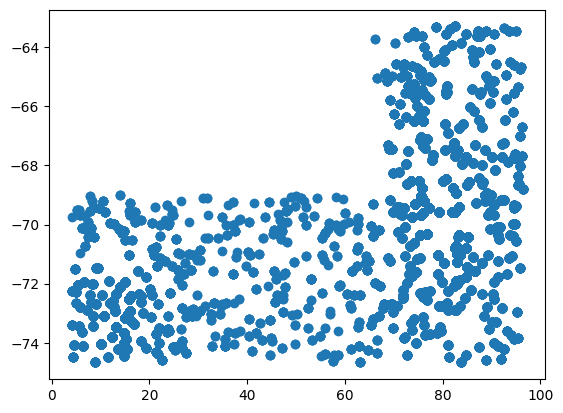

In [11]:
plt.scatter(all_in_apertures['center_ra'], all_in_apertures['center_dec'])

* Matching detections to clusters

In [16]:
import numpy as np
import pandas as pd
from astropy.coordinates import SkyCoord, search_around_sky, Angle
import astropy.units as u

def match_emitters_to_clusters(
    clusters: pd.DataFrame,
    stars: pd.DataFrame,
    *,
    cluster_ra_col: str = "ra",        # RA dos aglomerados (graus)
    cluster_dec_col: str = "dec",      # Dec dos aglomerados (graus)
    cluster_amaj_col: str = "amaj",    # semi-eixo maior (ex.: arcmin) — tratado como raio circular
    stars_ra_col: str = "ra",          # RA das estrelas (graus)
    stars_dec_col: str = "dec",        # Dec das estrelas (graus)
    amaj_unit: str = "arcmin",         # unidade do amaj (ex.: "arcmin", "arcsec", "deg")
    keep_cols_clusters: list | None = None,  # colunas extras do df de aglomerados para levar ao resultado
    keep_cols_stars: list | None = None,     # colunas extras do df de estrelas para levar ao resultado
) -> pd.DataFrame:
    """
    Associa estrelas Hα a aglomerados retornando apenas as que estão dentro do amaj de cada aglomerado.

    Parameters
    ----------
    clusters : pandas.DataFrame
        Tabela de aglomerados com colunas de posição e amaj.
    stars : pandas.DataFrame
        Tabela de estrelas emissoras com colunas de posição.
    cluster_ra_col : str, default "ra"
        Nome da coluna de RA dos aglomerados (em graus).
    cluster_dec_col : str, default "dec"
        Nome da coluna de Dec dos aglomerados (em graus).
    cluster_amaj_col : str, default "amaj"
        Nome da coluna do semi-eixo maior do aglomerado.
        **É interpretado como um raio circular** para a seleção.
    stars_ra_col : str, default "ra"
        Nome da coluna de RA das estrelas (em graus).
    stars_dec_col : str, default "dec"
        Nome da coluna de Dec das estrelas (em graus).
    amaj_unit : str, default "arcmin"
        Unidade de `amaj` (por exemplo: "arcmin", "arcsec" ou "deg").
    keep_cols_clusters : list[str] | None
        Colunas adicionais do DataFrame de aglomerados a incluir no resultado.
    keep_cols_stars : list[str] | None
        Colunas adicionais do DataFrame de estrelas a incluir no resultado.

    Returns
    -------
    pandas.DataFrame
        Uma tabela já mesclada contendo:
        - índices originais (`cluster_index`, `star_index`)
        - separação angular (`sep_arcsec`, `sep_arcmin`)
        - colunas dos aglomerados com prefixo `cluster_`
        - colunas das estrelas com prefixo `star_`

    Notes
    -----
    * `amaj` é tratado como **semi-eixo maior** em unidade dada por `amaj_unit` e
      usado como **raio circular equivalente** para o corte (i.e., sep <= amaj).
    * A rotina usa um raio máximo global (= max(amaj)) em `search_around_sky`
      e depois filtra par-a-par por `amaj` específico de cada aglomerado.
    * Linhas com posições/raios inválidos (NaN, não positivos) são ignoradas.
    """
    # Escolha das colunas para carregar/propagar
    if keep_cols_clusters is None:
        keep_cols_clusters = []
    if keep_cols_stars is None:
        keep_cols_stars = []

    # Filtrar entradas válidas nos aglomerados
    cl_req = [cluster_ra_col, cluster_dec_col, cluster_amaj_col] + keep_cols_clusters
    cl_df = clusters[cl_req].copy()
    cl_df = cl_df.replace([np.inf, -np.inf], np.nan).dropna(subset=[cluster_ra_col, cluster_dec_col, cluster_amaj_col])
    # descarta amaj <= 0
    cl_df = cl_df[cl_df[cluster_amaj_col] > 0].copy()

    # Filtrar entradas válidas nas estrelas
    st_req = [stars_ra_col, stars_dec_col] + keep_cols_stars
    st_df = stars[st_req].copy()
    st_df = st_df.replace([np.inf, -np.inf], np.nan).dropna(subset=[stars_ra_col, stars_dec_col])

    if cl_df.empty or st_df.empty:
        return pd.DataFrame(columns=[
            "cluster_index","star_index","sep_arcsec","sep_arcmin"
        ])

    # Coordenadas
    c_clusters = SkyCoord(ra=cl_df[cluster_ra_col].to_numpy() * u.deg,
                          dec=cl_df[cluster_dec_col].to_numpy() * u.deg)
    c_stars = SkyCoord(ra=st_df[stars_ra_col].to_numpy() * u.deg,
                       dec=st_df[stars_dec_col].to_numpy() * u.deg)

    # Raio máximo global para a busca
    unit = u.Unit(amaj_unit)
    max_amaj = np.nanmax(cl_df[cluster_amaj_col].to_numpy())
    seplimit = Angle(max_amaj, unit)

    # Busca inicial (eficiente)
    idx_cl, idx_st, sep2d, _ = search_around_sky(c_clusters, c_stars, seplimit=seplimit)

    if len(idx_cl) == 0:
        return pd.DataFrame(columns=[
            "cluster_index","star_index","sep_arcsec","sep_arcmin"
        ])

    # Limite específico por aglomerado (par-a-par)
    amaj_per_pair = Angle(cl_df.iloc[idx_cl][cluster_amaj_col].to_numpy(), unit)
    keep = sep2d <= amaj_per_pair

    if not np.any(keep):
        return pd.DataFrame(columns=[
            "cluster_index","star_index","sep_arcsec","sep_arcmin"
        ])

    # Construir resultado
    pairs = pd.DataFrame({
        "cluster_index": cl_df.index.values[idx_cl[keep]],
        "star_index": st_df.index.values[idx_st[keep]],
        "sep_arcsec": sep2d[keep].arcsec,
        "sep_arcmin": sep2d[keep].to(u.arcmin).value,
    })

    # Anexar metadados dos aglomerados e estrelas (com prefixos)
    cl_out = clusters.loc[pairs["cluster_index"]][[cluster_ra_col, cluster_dec_col, cluster_amaj_col] + keep_cols_clusters]
    cl_out = cl_out.add_prefix("cluster_").reset_index(drop=True)

    st_out = stars.loc[pairs["star_index"]][[stars_ra_col, stars_dec_col] + keep_cols_stars]
    st_out = st_out.add_prefix("star_").reset_index(drop=True)

    result = pd.concat([pairs.reset_index(drop=True), cl_out, st_out], axis=1)

    # Ordenar por separação (útil)
    result = result.sort_values("sep_arcmin", ascending=True).reset_index(drop=True)
    return result

In [17]:
bica =pd.read_csv('/home/shared/splus_gaia/data/h-alpha-selection-marina/MC/FullCatalogBica_08_20_Vizier.csv')

bica_c = bica[bica['Type'].isin(['C', 'CN', 'CA', 'CC', 'NC' ])]  # apenas aglomerados do tipo "C"

In [79]:
bica['[M/H]'].notna().sum()

134

In [16]:
bica.columns

Index(['Names', 'PA', 'bmin', 'l_logAge', 'logAge', 'r_logAge', '[M/H]',
       'r_[M/H]', 'PapI', 'B18', 'ra', 'dec', 'amaj', 'SimbadName', 'Type'],
      dtype='object')

In [19]:
# clusters_df: colunas ["name","ra","dec","amaj"] (amaj em arcmin, por ex.)
# emitters_df: colunas ["source_id","ra","dec", ...]
out = match_emitters_to_clusters(
    bica_c,
    mc_fields_clean[mc_fields_clean["unique_values_kept"] == 1],
    cluster_ra_col="ra",
    cluster_dec_col="dec",
    cluster_amaj_col="amaj",
    stars_ra_col="ra",
    stars_dec_col="dec",
    amaj_unit="arcmin",
    keep_cols_clusters=["Names"],         # traga o nome do aglomerado
    keep_cols_stars=["id"]  # traga id/atributos da estrela
)

In [10]:
out.columns

Index(['cluster_index', 'star_index', 'sep_arcsec', 'sep_arcmin', 'cluster_ra',
       'cluster_dec', 'cluster_amaj', 'cluster_Names', 'star_ra', 'star_dec',
       'star_id'],
      dtype='object')

In [20]:
mc_fields_clean["outside_cluster"] = ~mc_fields_clean["id"].isin(
    out["star_id"].unique()
)

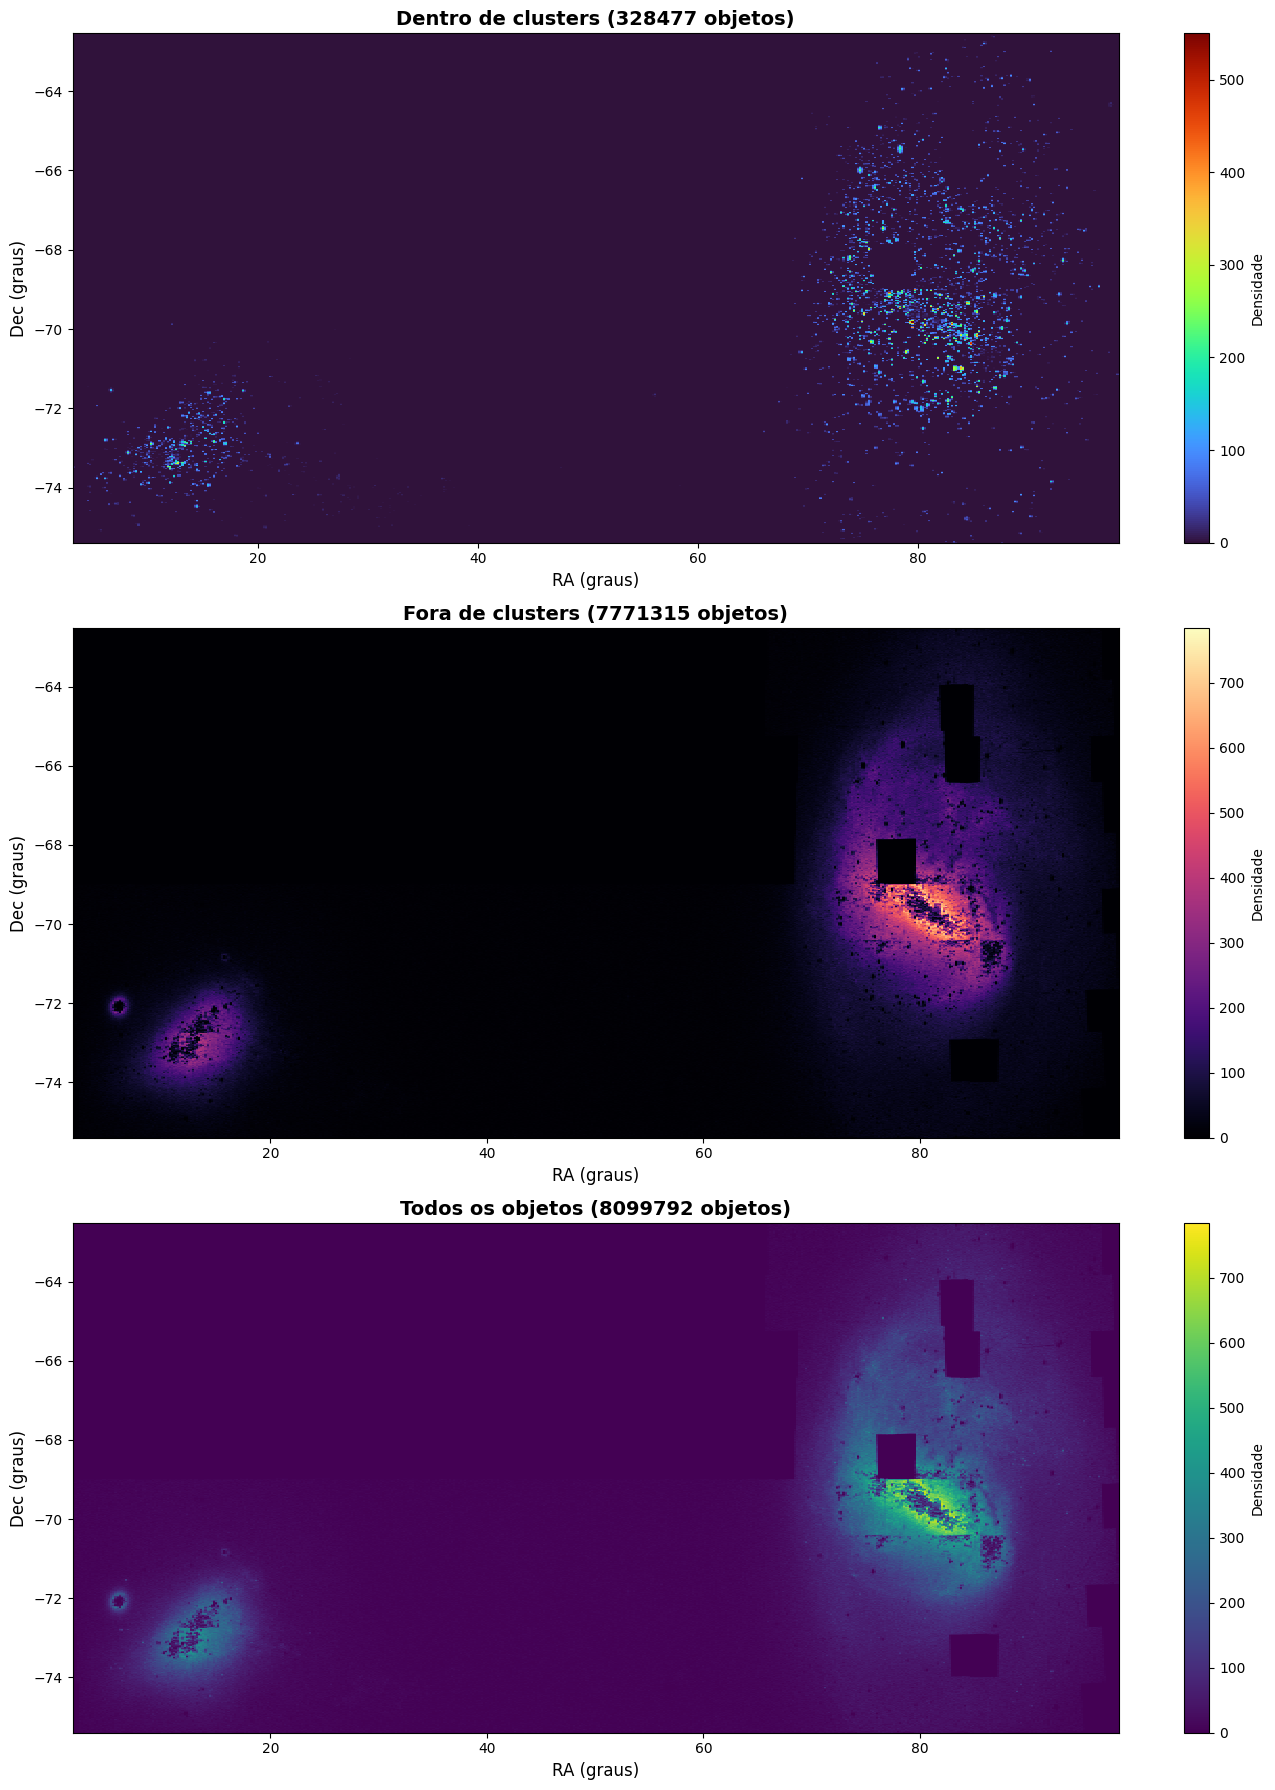

In [22]:
import matplotlib.pyplot as plt
import numpy as np


# Verificar se quer separar por 'outside_cluster'
if 'outside_cluster' in mc_fields_clean.columns:
    # Separar dados
    inside = mc_fields_clean[(mc_fields_clean['outside_cluster'] == 0) & (mc_fields_clean["unique_values_kept"] == 1)]
    outside = mc_fields_clean[(mc_fields_clean['outside_cluster'] == 1) & (mc_fields_clean["unique_values_kept"] == 1)]
    
    # Criar figura com 3 subplots na vertical
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 18))
    
    # Dentro dos clusters
    h1 = ax1.hist2d(inside['ra'], inside['dec'], bins=500, 
                    cmap='turbo', vmin=0)
    ax1.set_title(f'Dentro de clusters ({len(inside)} objetos)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('RA (graus)', fontsize=12)
    ax1.set_ylabel('Dec (graus)', fontsize=12)
    ax1.tick_params(labelsize=10)
    plt.colorbar(h1[3], ax=ax1, label='Densidade')
    
    # Fora dos clusters
    h2 = ax2.hist2d(outside['ra'], outside['dec'], bins=500, 
                    cmap='magma', vmin=0)
    ax2.set_title(f'Fora de clusters ({len(outside)} objetos)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('RA (graus)', fontsize=12)
    ax2.set_ylabel('Dec (graus)', fontsize=12)
    ax2.tick_params(labelsize=10)
    plt.colorbar(h2[3], ax=ax2, label='Densidade')
    
    # Todos juntos
    h3 = ax3.hist2d(mc_fields_clean[mc_fields_clean["unique_values_kept"] == 1]['ra'], mc_fields_clean[mc_fields_clean["unique_values_kept"] == 1]['dec'], bins=500, 
                    cmap='viridis')
    ax3.set_title(f'Todos os objetos ({len(mc_fields_clean[mc_fields_clean["unique_values_kept"] == 1])} objetos)', fontsize=14, fontweight='bold')
    ax3.set_xlabel('RA (graus)', fontsize=12)
    ax3.set_ylabel('Dec (graus)', fontsize=12)
    ax3.tick_params(labelsize=10)
    plt.colorbar(h3[3], ax=ax3, label='Densidade')
    
    plt.tight_layout()
    plt.show()

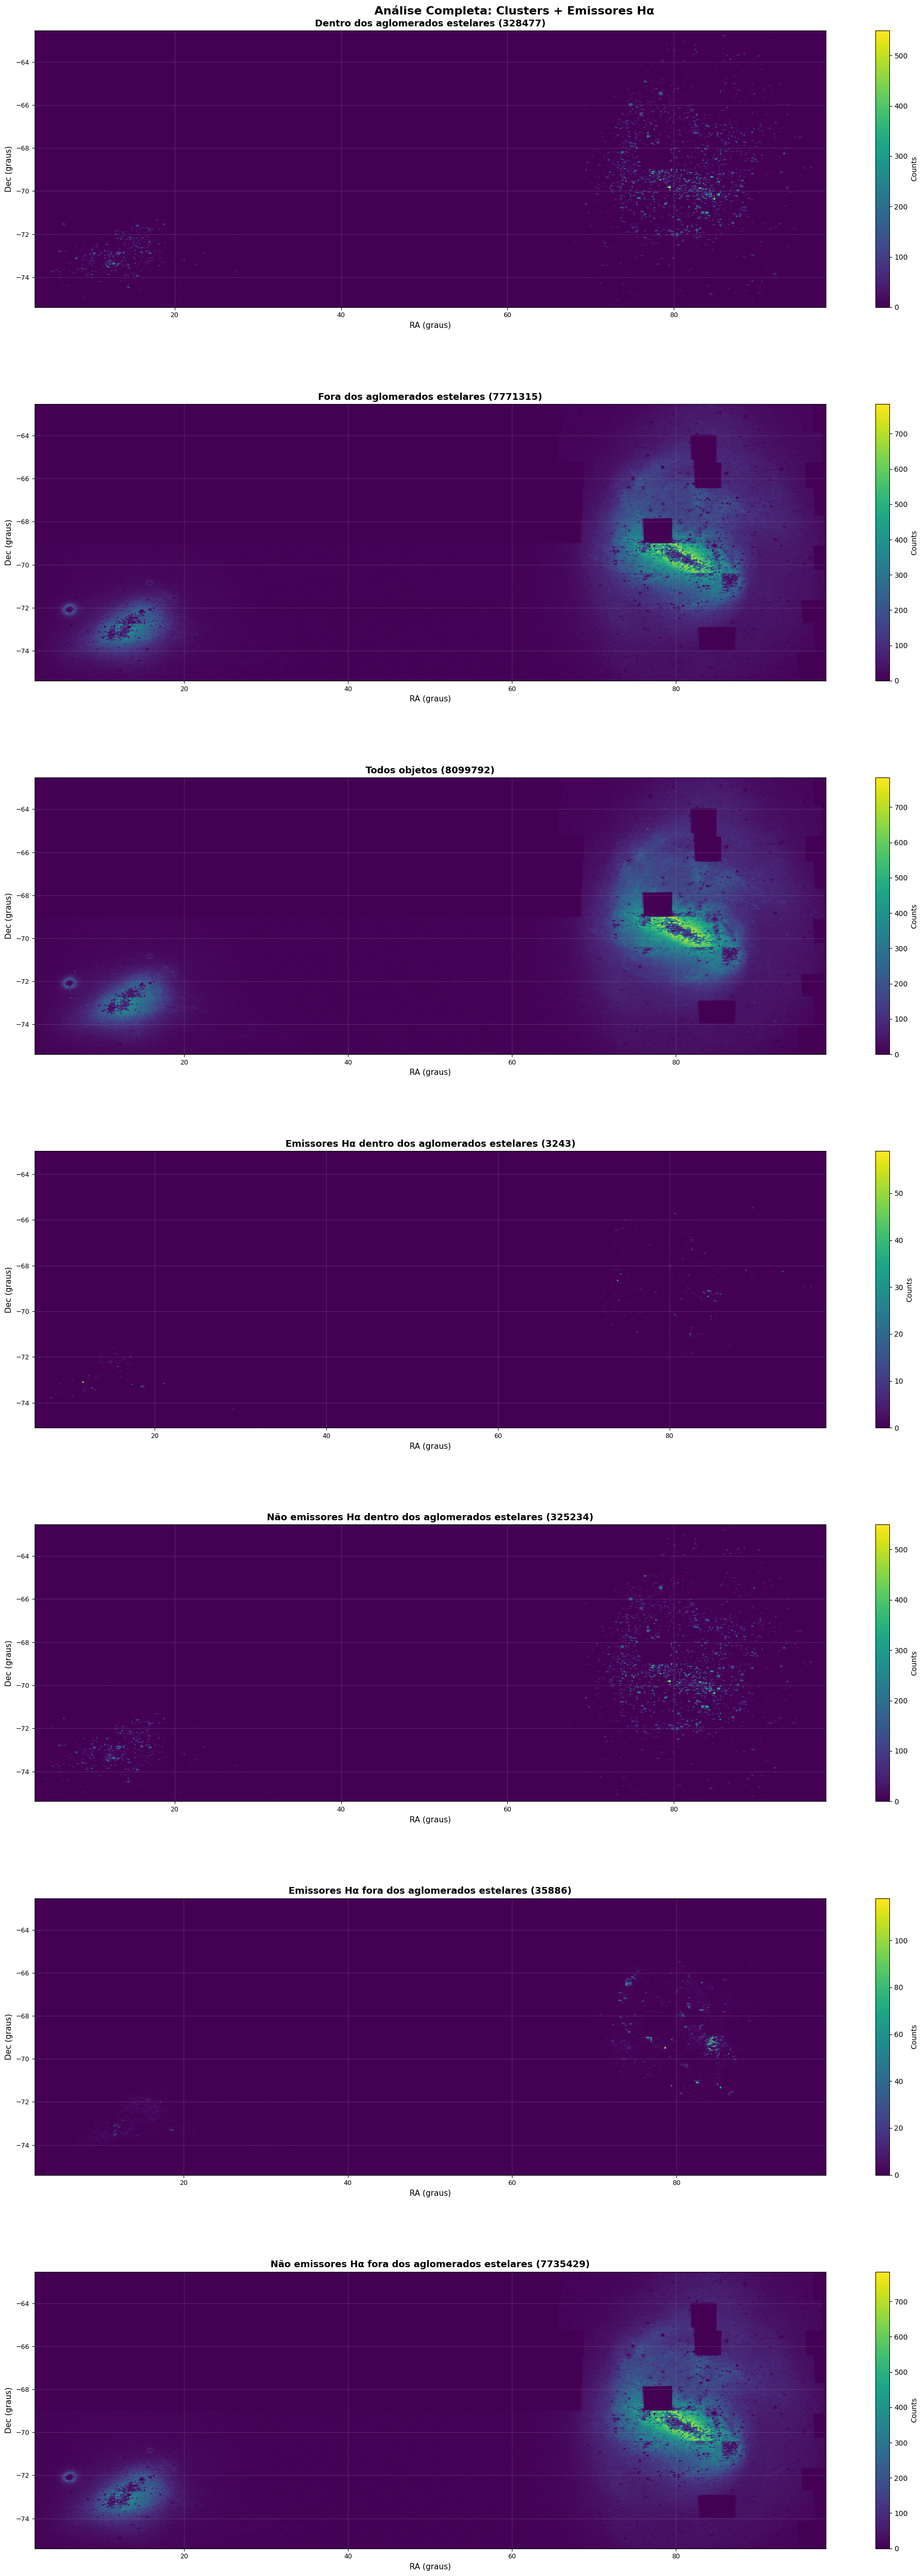

In [23]:
import matplotlib.pyplot as plt
import numpy as np

mc_used = mc_fields_clean[mc_fields_clean["unique_values_kept"] == 1]

if 'outside_cluster' in mc_used.columns and 'h_alpha_emitters_8sigma' in mc_used.columns:
    
    # Separar todos os grupos
    inside = mc_used[mc_used['outside_cluster'] == 0]
    outside = mc_used[mc_used['outside_cluster'] == 1]
    
    # Grupos combinados
    inside_emitters = inside[inside['h_alpha_emitters_8sigma'] == 1]
    inside_non_emitters = inside[inside['h_alpha_emitters_8sigma'] == 0]
    outside_emitters = outside[outside['h_alpha_emitters_8sigma'] == 1]
    outside_non_emitters = outside[outside['h_alpha_emitters_8sigma'] == 0]
    
    # Criar figura com 7 gráficos
    fig, axes = plt.subplots(7, 1, figsize=(20, 50))
    
    # Configurações para cada gráfico
    plots_config = [
        {'data': inside, 'title': f'Dentro dos aglomerados estelares ({len(inside)})', 'cmap': 'viridis'},
        {'data': outside, 'title': f'Fora dos aglomerados estelares ({len(outside)})', 'cmap': 'viridis'},
        {'data': mc_used, 'title': f'Todos objetos ({len(mc_used)})', 'cmap': 'viridis'},
        {'data': inside_emitters, 'title': f'Emissores Hα dentro dos aglomerados estelares ({len(inside_emitters)})', 'cmap': 'viridis'},
        {'data': inside_non_emitters, 'title': f'Não emissores Hα dentro dos aglomerados estelares ({len(inside_non_emitters)})', 'cmap': 'viridis'},
        {'data': outside_emitters, 'title': f'Emissores Hα fora dos aglomerados estelares ({len(outside_emitters)})', 'cmap': 'viridis'},
        {'data': outside_non_emitters, 'title': f'Não emissores Hα fora dos aglomerados estelares ({len(outside_non_emitters)})', 'cmap': 'viridis'}
    ]
    
    # Criar cada gráfico
    for i, (ax, config) in enumerate(zip(axes, plots_config)):
        if len(config['data']) > 0:
            h = ax.hist2d(config['data']['ra'], config['data']['dec'], 
                         bins=500, cmap=config['cmap'], vmin=0)
            ax.set_title(config['title'], fontsize=13, fontweight='bold')
            cbar = plt.colorbar(h[3], ax=ax)
            cbar.set_label('Counts', fontsize=10)
        else:
            ax.text(0.5, 0.5, 'Sem dados', ha='center', va='center', 
                   fontsize=12, transform=ax.transAxes)
            ax.set_title(config['title'] + ' (vazio)', fontsize=13, fontweight='bold')
        
        ax.set_xlabel('RA (graus)', fontsize=11)
        ax.set_ylabel('Dec (graus)', fontsize=11)
        ax.tick_params(labelsize=9)
        ax.grid(alpha=0.2)
    
    plt.suptitle('Análise Completa: Clusters + Emissores Hα', 
                fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.35)
    plt.show()

/tmp/ipykernel_97277/3301177738.py:105: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


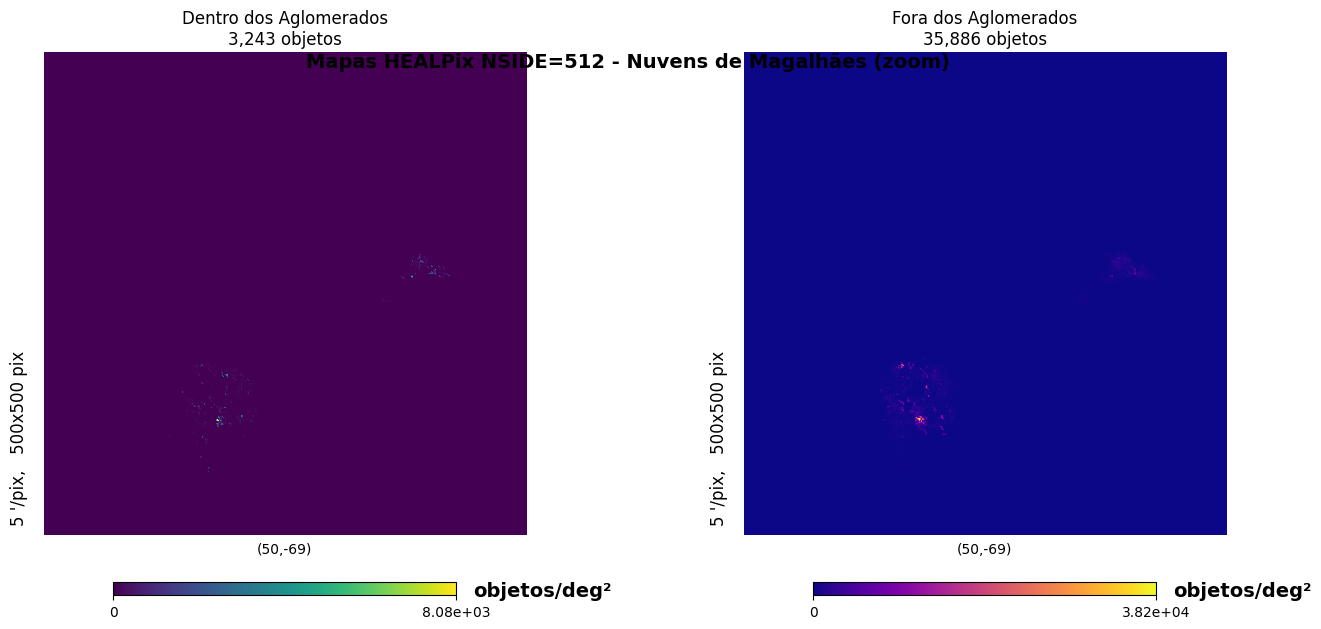


=== DENTRO aglomerados ===
npix_nonzero        : 821 / 3,145,728
area_covered_deg2   : 10.767
total_objects_est   : 3243
mean_density        : 301.210 obj/deg²
median_density      : 76.255 obj/deg²
p90_density         : 610.037 obj/deg²
p99_density         : 2836.671 obj/deg²
max_density         : 8082.987 obj/deg²

=== FORA aglomerados ===
npix_nonzero        : 6,415 / 3,145,728
area_covered_deg2   : 84.126
total_objects_est   : 35886
mean_density        : 426.574 obj/deg²
median_density      : 152.509 obj/deg²
p90_density         : 762.546 obj/deg²
p99_density         : 5555.910 obj/deg²
max_density         : 38203.554 obj/deg²


In [56]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp

mc_used = mc_fields_clean[(mc_fields_clean["unique_values_kept"] == 1) & (mc_fields_clean['h_alpha_emitters_8sigma'] == 1)]

# Configuração HEALPix
nside = 512
npix = hp.nside2npix(nside)
pixel_area_deg2 = hp.nside2pixarea(nside, degrees=True)

def create_density_map(data, ra_col="ra", dec_col="dec"):
    if len(data) == 0:
        return np.zeros(npix, dtype=float)

    theta = np.deg2rad(90.0 - data[dec_col].to_numpy())  # colatitude
    phi   = np.deg2rad(data[ra_col].to_numpy() % 360.0)  # longitude
    pix = hp.ang2pix(nside, theta, phi)
    counts = np.bincount(pix, minlength=npix).astype(float)
    return counts / pixel_area_deg2

def healpix_density_stats(density_map):
    """
    Estatísticas do mapa de densidade (objetos/deg²).
    Considera apenas pixels com densidade > 0 como 'área coberta'.
    """
    m = np.asarray(density_map, float)
    nonzero = m > 0
    area_deg2 = nonzero.sum() * pixel_area_deg2

    stats = {
        "npix_total": int(m.size),
        "npix_nonzero": int(nonzero.sum()),
        "area_covered_deg2": float(area_deg2),
        "mean_density_nonzero": float(m[nonzero].mean()) if nonzero.any() else 0.0,
        "median_density_nonzero": float(np.median(m[nonzero])) if nonzero.any() else 0.0,
        "p90_density_nonzero": float(np.percentile(m[nonzero], 90)) if nonzero.any() else 0.0,
        "p99_density_nonzero": float(np.percentile(m[nonzero], 99)) if nonzero.any() else 0.0,
        "max_density": float(m.max()) if m.size else 0.0,
        "total_objects_est": float(m.sum() * pixel_area_deg2),  # integra densidade
    }
    return stats

# Separar dados
inside  = mc_used[mc_used["outside_cluster"] == 0]
outside = mc_used[mc_used["outside_cluster"] == 1]

density_in  = create_density_map(inside)
density_out = create_density_map(outside)

# Estatísticas
stats_in = healpix_density_stats(density_in)
stats_out = healpix_density_stats(density_out)

# Centro das MC
rot = (50, -69, 45)

# Zoom
xsize = 500
reso  = 5.0  # arcmin/pixel

plt.figure(figsize=(14, 6))

hp.gnomview(
    density_in,
    rot=rot,
    xsize=xsize,
    reso=reso,
    title=f'Dentro dos Aglomerados\n{len(inside):,} objetos',
    unit='objetos/deg²',
    cmap='viridis',
    min=0,
    sub=(1, 2, 1),
    notext=False,   # ✅ deixa o healpy desenhar ticks/labels de coord
    cbar=True
)

hp.gnomview(
    density_out,
    rot=rot,
    xsize=xsize,
    reso=reso,
    title=f'Fora dos Aglomerados\n{len(outside):,} objetos',
    unit='objetos/deg²',
    cmap='plasma',
    min=0,
    sub=(1, 2, 2),
    notext=False,
    cbar=True
)

# ✅ Pega os eixos corretos criados pelo healpy e adiciona grid
fig = plt.gcf()
axes = fig.get_axes()

# Os dois primeiros eixos costumam ser os mapas; as colorbars virão depois.
# Vamos tentar pegar os dois primeiros "Axes" que não são colorbar.
map_axes = [ax for ax in axes if ax.get_label() != '<colorbar>'][:2]

for ax in map_axes:
    ax.grid(alpha=0.3)

plt.suptitle(f'Mapas HEALPix NSIDE={nside} - Nuvens de Magalhães (zoom)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --- imprime estatísticas
def pretty_print_stats(name, s):
    print(f"\n=== {name} ===")
    print(f"npix_nonzero        : {s['npix_nonzero']:,} / {s['npix_total']:,}")
    print(f"area_covered_deg2   : {s['area_covered_deg2']:.3f}")
    print(f"total_objects_est   : {s['total_objects_est']:.0f}")
    print(f"mean_density        : {s['mean_density_nonzero']:.3f} obj/deg²")
    print(f"median_density      : {s['median_density_nonzero']:.3f} obj/deg²")
    print(f"p90_density         : {s['p90_density_nonzero']:.3f} obj/deg²")
    print(f"p99_density         : {s['p99_density_nonzero']:.3f} obj/deg²")
    print(f"max_density         : {s['max_density']:.3f} obj/deg²")

pretty_print_stats("DENTRO aglomerados", stats_in)
pretty_print_stats("FORA aglomerados", stats_out)

In [40]:
td = pd.read_csv('/home/shared/splus_gaia/data/h-alpha-selection-marina/MC/Be_stars/splus_figueiredo_objects_all.csv')

bes = pd.read_csv('/home/shared/splus_gaia/data/h-alpha-selection-marina/MC/Be_stars/be_stars_smc_lmc.csv')

bes['OGLE'] = bes['OGLE'].str.upper()

be = pd.merge(td, bes, right_on='OGLE', left_on='OGLE-II', how='inner')

In [50]:
mc_fields_clean.columns

Index(['id', 'ra', 'dec', 'mag_psf_g', 'mag_psf_i', 'mag_psf_j0378',
       'mag_psf_j0395', 'mag_psf_j0410', 'mag_psf_j0430', 'mag_psf_j0515',
       'mag_psf_j0660', 'mag_psf_j0861', 'mag_psf_r', 'mag_psf_u', 'mag_psf_z',
       'err_mag_psf_g', 'err_mag_psf_i', 'err_mag_psf_j0378',
       'err_mag_psf_j0395', 'err_mag_psf_j0410', 'err_mag_psf_j0430',
       'err_mag_psf_j0515', 'err_mag_psf_j0660', 'err_mag_psf_j0861',
       'err_mag_psf_r', 'err_mag_psf_u', 'err_mag_psf_z',
       'h_alpha_emitters_8sigma', 's2noise_r', 'unique_values_kept',
       'outside_cluster'],
      dtype='object')

In [51]:
mc_fields_clean.to_csv('/home/shared/splus_gaia/data/h-alpha-selection-marina/MC/mc_all_additional_info.csv', index=False)

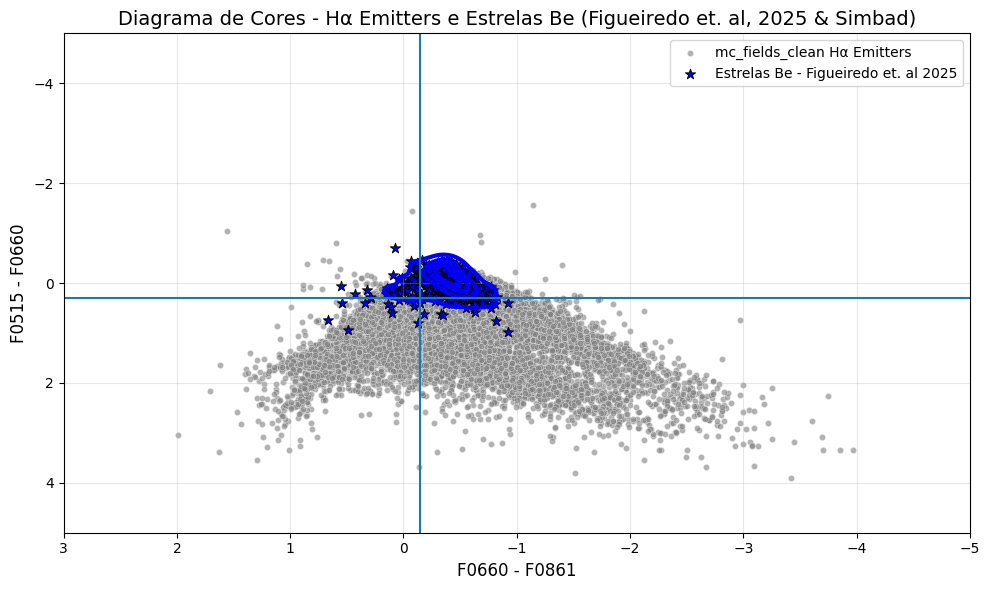

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Configurar a figura
plt.figure(figsize=(10, 6))
mc_fields_outside = mc_fields_clean[(mc_fields_clean['outside_cluster'] == True) & (mc_fields_clean["unique_values_kept"] == 1)& (mc_fields_clean['h_alpha_emitters_8sigma'] == 1)]
# Plotar o scatter dos dados principais
sns.scatterplot(y=mc_fields_outside['mag_psf_j0515'] - mc_fields_outside['mag_psf_j0660'], 
                x=mc_fields_outside['mag_psf_j0660'] - mc_fields_outside['mag_psf_j0861'], 
                label='mc_fields_clean Hα Emitters', color='gray', s=20, alpha=0.6)
# Plotar o scatter das estrelas Be
sns.scatterplot(y=be['mag_psf_j0515'] - be['mag_psf_j0660'], 
                x=be['mag_psf_j0660'] - be['mag_psf_j0861'], 
                label='Estrelas Be - Figueiredo et. al 2025', color='blue', s=60, 
                marker='*', edgecolor='black')

# Adicionar o contorno (densidade) para os dados 'be'
# Opção 1: Contorno de densidade (recomendado)
sns.kdeplot(x=be['mag_psf_j0660'] - be['mag_psf_j0861'],
            y=be['mag_psf_j0515'] - be['mag_psf_j0660'],
            color='blue', linewidths=3, levels=5)

# Opção 2: Se preferir contornos mais suaves
# sns.kdeplot(x=be['mag_psf_j0660'] - be['mag_psf_j0861'],
#             y=be['mag_psf_j0515'] - be['mag_psf_j0660'],
#             fill=True, alpha=0.3, color='blue', thresh=0.1)

# Opção 3: Se quiser um contorno com hexbin (para muitos pontos)
# plt.hexbin(x=be['mag_psf_j0660'] - be['mag_psf_j0861'],
#            y=be['mag_psf_j0515'] - be['mag_psf_j0660'],
#            gridsize=30, cmap='Blues', alpha=0.7)

# Configurações dos eixos
plt.ylim(5, -5)
plt.xlim(3, -5)

plt.axvline(-0.15)
plt.axhline(0.3)

# Rótulos e título
plt.xlabel('F0660 - F0861', fontsize=12)
plt.ylabel('F0515 - F0660', fontsize=12)
plt.title('Diagrama de Cores - Hα Emitters e Estrelas Be (Figueiredo et. al, 2025 & Simbad)', fontsize=14)

# Adicionar grade para melhor visualização
plt.grid(True, alpha=0.3)

# Legenda
plt.legend(loc='best', fontsize=10)

# Ajustar layout
plt.tight_layout()

plt.show()

In [69]:
be_selection_field = mc_fields_clean[(mc_fields_clean['outside_cluster'] == 1) &
                                      (mc_fields_clean["unique_values_kept"] == 1)&
                                        (mc_fields_clean['h_alpha_emitters_8sigma'] == 1) &
                                           (mc_fields_clean['mag_psf_j0515'] - mc_fields_clean['mag_psf_j0660'] < 0.3) &
                                            (mc_fields_clean['mag_psf_j0660'] - mc_fields_clean['mag_psf_j0861'] < -0.15)]

In [70]:
be_selection_field

,id,ra,dec,mag_psf_g,mag_psf_i,mag_psf_j0378,mag_psf_j0395,mag_psf_j0410,mag_psf_j0430,mag_psf_j0515,...,err_mag_psf_j0515,err_mag_psf_j0660,err_mag_psf_j0861,err_mag_psf_r,err_mag_psf_u,err_mag_psf_z,h_alpha_emitters_8sigma,s2noise_r,unique_values_kept,outside_cluster
7855695,i06MC00260158A,86.178639,-66.435367,12.683394,13.335740,12.439654,12.457236,12.499182,12.580618,12.762511,...,0.001446,0.001011,0.001896,0.000581,0.000885,0.001409,True,22382.374378,1,True
31980204,i06MC009508KU1,15.716418,-71.806883,12.795359,13.402849,12.520007,12.410026,12.525247,12.609097,12.839441,...,0.001073,0.000733,0.001376,0.000601,0.000954,0.001009,True,21767.337330,1,True
12393833,i06MC003408Z8G,86.507193,-66.990068,13.385091,13.442224,13.644942,13.445026,13.312436,13.376219,13.395643,...,0.001840,0.000998,0.001812,0.000624,0.001903,0.001304,True,21306.721576,1,True
31381732,i06MC009406QL2,12.618414,-72.150885,12.920452,13.319850,12.821718,12.755581,12.742403,12.787489,12.917931,...,0.001271,0.000740,0.001248,0.000618,0.000922,0.001338,True,21200.968883,1,True
31385282,i06MC009406XCJ,13.071394,-72.146334,13.040941,13.259908,12.835981,12.895915,12.921067,12.958897,13.044461,...,0.001359,0.000674,0.001277,0.000627,0.000702,0.001370,True,20963.003594,1,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20286537,i06MC006305797,73.571816,-69.995338,19.193542,19.480723,19.504519,19.188140,19.119029,19.255986,19.171083,...,0.055036,0.029909,0.088412,0.037274,0.084663,0.073386,True,517.101138,1,True
9867578,i06MC00300B6FN,74.015003,-66.558511,19.071112,19.467394,19.494203,19.128286,18.594726,19.082267,19.036129,...,0.075707,0.035960,0.128254,0.039510,0.112537,0.109547,True,488.976153,1,True
9650465,i06MC003006NCF,73.758707,-67.184056,19.198605,19.612953,19.548807,19.099738,18.927807,19.070256,18.998267,...,0.074046,0.036002,0.130471,0.039619,NaN,0.084249,True,488.535689,1,True
9864647,i06MC00300B8AT,74.061426,-66.549042,19.248112,19.532031,19.627649,19.214663,19.011992,19.094037,19.014828,...,0.074634,0.033188,0.141364,0.040875,0.134819,0.151607,True,473.527452,1,True


/tmp/ipykernel_97277/2223389041.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


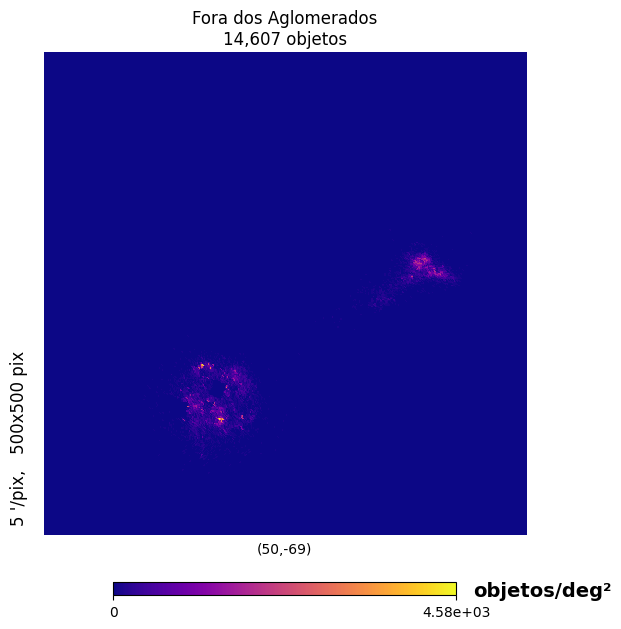


=== FORA aglomerados ===
npix_nonzero        : 3,743 / 3,145,728
area_covered_deg2   : 49.086
total_objects_est   : 14607
mean_density        : 297.582 obj/deg²
median_density      : 152.509 obj/deg²
p90_density         : 686.291 obj/deg²
p99_density         : 1753.856 obj/deg²
max_density         : 4575.276 obj/deg²


In [73]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp

mc_used = be_selection_field

# Configuração HEALPix
nside = 512
npix = hp.nside2npix(nside)
pixel_area_deg2 = hp.nside2pixarea(nside, degrees=True)

def create_density_map(data, ra_col="ra", dec_col="dec"):
    if len(data) == 0:
        return np.zeros(npix, dtype=float)

    theta = np.deg2rad(90.0 - data[dec_col].to_numpy())  # colatitude
    phi   = np.deg2rad(data[ra_col].to_numpy() % 360.0)  # longitude
    pix = hp.ang2pix(nside, theta, phi)
    counts = np.bincount(pix, minlength=npix).astype(float)
    return counts / pixel_area_deg2

def healpix_density_stats(density_map):
    """
    Estatísticas do mapa de densidade (objetos/deg²).
    Considera apenas pixels com densidade > 0 como 'área coberta'.
    """
    m = np.asarray(density_map, float)
    nonzero = m > 0
    area_deg2 = nonzero.sum() * pixel_area_deg2

    stats = {
        "npix_total": int(m.size),
        "npix_nonzero": int(nonzero.sum()),
        "area_covered_deg2": float(area_deg2),
        "mean_density_nonzero": float(m[nonzero].mean()) if nonzero.any() else 0.0,
        "median_density_nonzero": float(np.median(m[nonzero])) if nonzero.any() else 0.0,
        "p90_density_nonzero": float(np.percentile(m[nonzero], 90)) if nonzero.any() else 0.0,
        "p99_density_nonzero": float(np.percentile(m[nonzero], 99)) if nonzero.any() else 0.0,
        "max_density": float(m.max()) if m.size else 0.0,
        "total_objects_est": float(m.sum() * pixel_area_deg2),  # integra densidade
    }
    return stats

# Separar dados

outside = mc_used[mc_used["outside_cluster"] == 1]


density_out = create_density_map(outside)

# Estatísticas

stats_out = healpix_density_stats(density_out)

# Centro das MC
rot = (50, -69, 45)

# Zoom
xsize = 500
reso  = 5.0  # arcmin/pixel

plt.figure(figsize=(14, 6))


hp.gnomview(
    density_out,
    rot=rot,
    xsize=xsize,
    reso=reso,
    title=f'Fora dos Aglomerados\n{len(outside):,} objetos',
    unit='objetos/deg²',
    cmap='plasma',
    min=0,
    sub=(1, 2, 2),
    notext=False,
    cbar=True
)

# ✅ Pega os eixos corretos criados pelo healpy e adiciona grid
fig = plt.gcf()
axes = fig.get_axes()

# Os dois primeiros eixos costumam ser os mapas; as colorbars virão depois.
# Vamos tentar pegar os dois primeiros "Axes" que não são colorbar.
map_axes = [ax for ax in axes if ax.get_label() != '<colorbar>'][:2]

for ax in map_axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- imprime estatísticas
def pretty_print_stats(name, s):
    print(f"\n=== {name} ===")
    print(f"npix_nonzero        : {s['npix_nonzero']:,} / {s['npix_total']:,}")
    print(f"area_covered_deg2   : {s['area_covered_deg2']:.3f}")
    print(f"total_objects_est   : {s['total_objects_est']:.0f}")
    print(f"mean_density        : {s['mean_density_nonzero']:.3f} obj/deg²")
    print(f"median_density      : {s['median_density_nonzero']:.3f} obj/deg²")
    print(f"p90_density         : {s['p90_density_nonzero']:.3f} obj/deg²")
    print(f"p99_density         : {s['p99_density_nonzero']:.3f} obj/deg²")
    print(f"max_density         : {s['max_density']:.3f} obj/deg²")

pretty_print_stats("FORA aglomerados", stats_out)

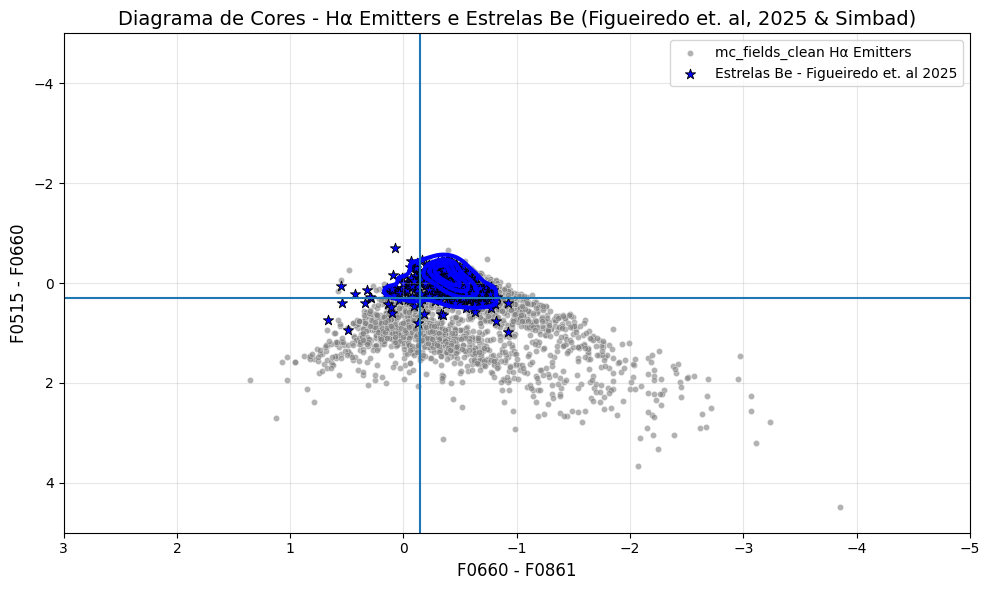

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Configurar a figura
plt.figure(figsize=(10, 6))
mc_fields_inside = mc_fields_clean[(mc_fields_clean['outside_cluster'] == False) & (mc_fields_clean["unique_values_kept"] == 1)& (mc_fields_clean['h_alpha_emitters_8sigma'] == 1)]
# Plotar o scatter dos dados principais
sns.scatterplot(y=mc_fields_inside['mag_psf_j0515'] - mc_fields_inside['mag_psf_j0660'], 
                x=mc_fields_inside['mag_psf_j0660'] - mc_fields_inside['mag_psf_j0861'], 
                label='mc_fields_clean Hα Emitters', color='gray', s=20, alpha=0.6)
# Plotar o scatter das estrelas Be
sns.scatterplot(y=be['mag_psf_j0515'] - be['mag_psf_j0660'], 
                x=be['mag_psf_j0660'] - be['mag_psf_j0861'], 
                label='Estrelas Be - Figueiredo et. al 2025', color='blue', s=60, 
                marker='*', edgecolor='black')

# Adicionar o contorno (densidade) para os dados 'be'
# Opção 1: Contorno de densidade (recomendado)
sns.kdeplot(x=be['mag_psf_j0660'] - be['mag_psf_j0861'],
            y=be['mag_psf_j0515'] - be['mag_psf_j0660'],
            color='blue', linewidths=3, levels=5)

# Opção 2: Se preferir contornos mais suaves
# sns.kdeplot(x=be['mag_psf_j0660'] - be['mag_psf_j0861'],
#             y=be['mag_psf_j0515'] - be['mag_psf_j0660'],
#             fill=True, alpha=0.3, color='blue', thresh=0.1)

# Opção 3: Se quiser um contorno com hexbin (para muitos pontos)
# plt.hexbin(x=be['mag_psf_j0660'] - be['mag_psf_j0861'],
#            y=be['mag_psf_j0515'] - be['mag_psf_j0660'],
#            gridsize=30, cmap='Blues', alpha=0.7)

# Configurações dos eixos
plt.ylim(5, -5)
plt.xlim(3, -5)

plt.axvline(-0.15)
plt.axhline(0.3)

# Rótulos e título
plt.xlabel('F0660 - F0861', fontsize=12)
plt.ylabel('F0515 - F0660', fontsize=12)
plt.title('Diagrama de Cores - Hα Emitters e Estrelas Be (Figueiredo et. al, 2025 & Simbad)', fontsize=14)

# Adicionar grade para melhor visualização
plt.grid(True, alpha=0.3)

# Legenda
plt.legend(loc='best', fontsize=10)

# Ajustar layout
plt.tight_layout()

plt.show()

In [80]:
be_selection_clusters = mc_fields_clean[(mc_fields_clean['outside_cluster'] == 0) &
                                      (mc_fields_clean["unique_values_kept"] == 1)&
                                        (mc_fields_clean['h_alpha_emitters_8sigma'] == 1) &
                                           (mc_fields_clean['mag_psf_j0515'] - mc_fields_clean['mag_psf_j0660'] < 0.3) &
                                            (mc_fields_clean['mag_psf_j0660'] - mc_fields_clean['mag_psf_j0861'] < -0.15)]

In [82]:
out

,cluster_index,star_index,sep_arcsec,sep_arcmin,cluster_ra,cluster_dec,cluster_amaj,cluster_Names,star_ra,star_dec,star_id
0,5101,40606850,0.072797,0.001213,80.995833,-72.910556,0.55,OHSC15,80.995796,-72.910573,i06MC01290982F
1,3292,37307446,0.096054,0.001601,10.595000,-73.088611,0.30,H86-71,10.594916,-73.088600,i06MC011409PCI
2,2681,21521147,0.103843,0.001731,84.570833,-69.725000,0.90,BSDL2654,84.570912,-69.725009,i06MC006507M5L
3,4152,23779537,0.122086,0.002035,92.933333,-69.341944,0.50,KMHK1683,92.933246,-69.341930,i06MC00680544V
4,3111,19903926,0.133361,0.002223,76.075000,-70.066667,1.46,GKK-O150,76.074950,-70.066700,i06MC0063049VX
...,...,...,...,...,...,...,...,...,...,...,...
342698,4847,7052582,329.622796,5.493713,78.412500,-65.465000,5.50,NGC1866,78.235793,-65.410337,i06MC002309BW6
342699,4847,7043851,329.679213,5.494654,78.412500,-65.465000,5.50,NGC1866,78.574418,-65.527262,i06MC002308G5C
342700,4847,7046894,329.712229,5.495204,78.412500,-65.465000,5.50,NGC1866,78.596473,-65.414594,i06MC0023099L2
342701,4847,7052753,329.776236,5.496271,78.412500,-65.465000,5.50,NGC1866,78.282895,-65.390927,i06MC002309G6A


In [83]:
be_selection_clusters = be_selection_clusters.merge(out[['star_id', 'cluster_Names', 'cluster_ra', 'cluster_dec']], left_on='id', right_on='star_id', how='left')

/tmp/ipykernel_97277/4144480623.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


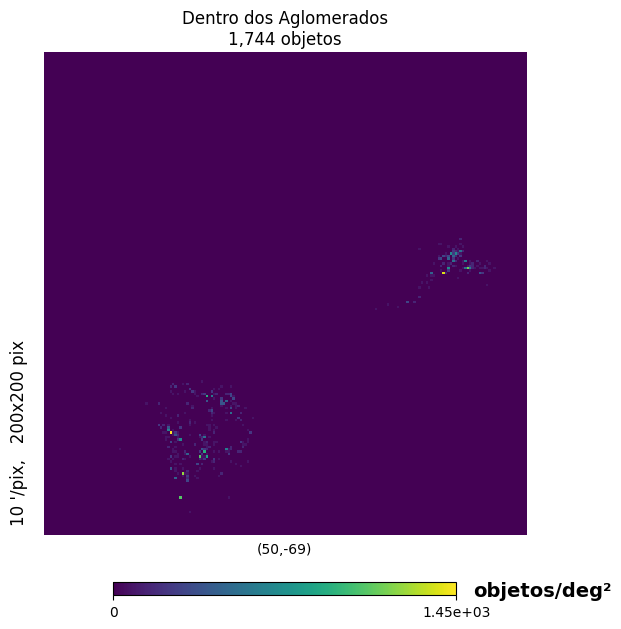


=== DENTRO dos aglomerados ===
npix_nonzero        : 668 / 3,145,728
area_covered_deg2   : 8.760
total_objects_est   : 1744
mean_density        : 199.084 obj/deg²
median_density      : 76.255 obj/deg²
p90_density         : 457.528 obj/deg²
p99_density         : 1220.074 obj/deg²
max_density         : 3736.475 obj/deg²


In [93]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp

mc_used = be_selection_clusters

# Configuração HEALPix
nside = 512
npix = hp.nside2npix(nside)
pixel_area_deg2 = hp.nside2pixarea(nside, degrees=True)

def create_density_map(data, ra_col="ra", dec_col="dec"):
    if len(data) == 0:
        return np.zeros(npix, dtype=float)

    theta = np.deg2rad(90.0 - data[dec_col].to_numpy())  # colatitude
    phi   = np.deg2rad(data[ra_col].to_numpy() % 360.0)  # longitude
    pix = hp.ang2pix(nside, theta, phi)
    counts = np.bincount(pix, minlength=npix).astype(float)
    return counts / pixel_area_deg2

def healpix_density_stats(density_map):
    """
    Estatísticas do mapa de densidade (objetos/deg²).
    Considera apenas pixels com densidade > 0 como 'área coberta'.
    """
    m = np.asarray(density_map, float)
    nonzero = m > 0
    area_deg2 = nonzero.sum() * pixel_area_deg2

    stats = {
        "npix_total": int(m.size),
        "npix_nonzero": int(nonzero.sum()),
        "area_covered_deg2": float(area_deg2),
        "mean_density_nonzero": float(m[nonzero].mean()) if nonzero.any() else 0.0,
        "median_density_nonzero": float(np.median(m[nonzero])) if nonzero.any() else 0.0,
        "p90_density_nonzero": float(np.percentile(m[nonzero], 90)) if nonzero.any() else 0.0,
        "p99_density_nonzero": float(np.percentile(m[nonzero], 99)) if nonzero.any() else 0.0,
        "max_density": float(m.max()) if m.size else 0.0,
        "total_objects_est": float(m.sum() * pixel_area_deg2),  # integra densidade
    }
    return stats

# Separar dados

inside = mc_used[mc_used["outside_cluster"] == 0]


density_inside = create_density_map(inside)

# Estatísticas

stats_inside = healpix_density_stats(density_inside)
# Centro das MC
rot = (50, -69, 45)

# Zoom
xsize = 200
reso  = 10.0  # arcmin/pixel

plt.figure(figsize=(14, 6))


hp.gnomview(
    density_inside,
    rot=rot,
    xsize=xsize,
    reso=reso,
    title=f'Dentro dos Aglomerados\n{len(inside):,} objetos',
    unit='objetos/deg²',
    cmap='viridis',
    min=0,
    sub=(1, 2, 2),
    notext=False,
    cbar=True
)

# ✅ Pega os eixos corretos criados pelo healpy e adiciona grid
fig = plt.gcf()
axes = fig.get_axes()

# Os dois primeiros eixos costumam ser os mapas; as colorbars virão depois.
# Vamos tentar pegar os dois primeiros "Axes" que não são colorbar.
map_axes = [ax for ax in axes if ax.get_label() != '<colorbar>'][:2]

for ax in map_axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- imprime estatísticas
def pretty_print_stats(name, s):
    print(f"\n=== {name} ===")
    print(f"npix_nonzero        : {s['npix_nonzero']:,} / {s['npix_total']:,}")
    print(f"area_covered_deg2   : {s['area_covered_deg2']:.3f}")
    print(f"total_objects_est   : {s['total_objects_est']:.0f}")
    print(f"mean_density        : {s['mean_density_nonzero']:.3f} obj/deg²")
    print(f"median_density      : {s['median_density_nonzero']:.3f} obj/deg²")
    print(f"p90_density         : {s['p90_density_nonzero']:.3f} obj/deg²")
    print(f"p99_density         : {s['p99_density_nonzero']:.3f} obj/deg²")
    print(f"max_density         : {s['max_density']:.3f} obj/deg²")

pretty_print_stats("DENTRO dos aglomerados", stats_inside)

Text(0.5, 1.0, 'H-alpha emitters - spacial distribution over the clouds (inside vs outside clusters)')

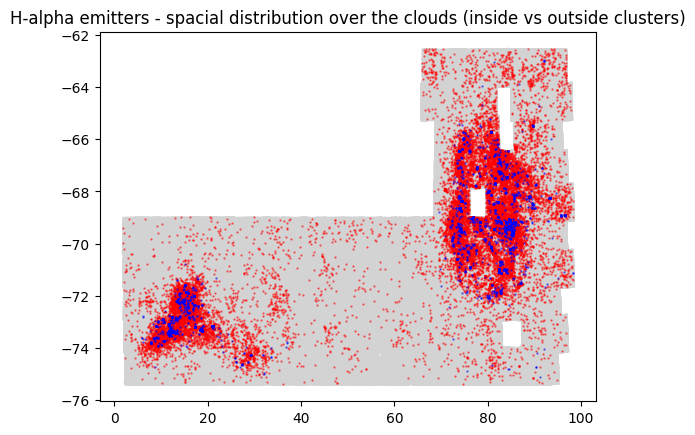

In [64]:

plt.scatter(mc_fields_clean[(mc_fields_clean["unique_values_kept"] == 1)&(mc_fields_clean['h_alpha_emitters_8sigma'] == 0)]['ra'], mc_fields_clean[(mc_fields_clean["unique_values_kept"] == 1)&(mc_fields_clean['h_alpha_emitters_8sigma'] == 0)]['dec'], color='lightgray', s=0.5, alpha=0.3)
plt.scatter(mc_fields_outside['ra'], mc_fields_outside['dec'], color='red', s=0.5, alpha=0.5)
plt.scatter(mc_fields_inside['ra'], mc_fields_inside['dec'], color='blue', s=0.5, alpha=0.5)


plt.title('H-alpha emitters - spacial distribution over the clouds (inside vs outside clusters)')